# Task 1 - Step 1: Class-balanced evaluation subset and head split

Two data products are created here:

1. **Evaluation subset** - 500 images from the *official STL-10 test split*, class balanced (50 per class), selected with seed 6304. Image identifiers are saved so the subset can be reproduced and audited. Every model, clean and transformed, sees exactly these images.
2. **Head split** - stratified 80/20 train/validation split of the official training partition (seed 6304) used to train the linear heads.

All evaluation images are resized once to **224x224 RGB** (bicubic) and stored as `uint8` so all interventions start from one common image before model-specific normalisation.

In [1]:
# ---- Common header (identical in every Task 1 notebook) ----
import json, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Locate the task1/ folder no matter where Jupyter was launched from.
ROOT = Path.cwd()
if not (ROOT / "configs").exists() and (ROOT / "task1" / "configs").exists():
    ROOT = ROOT / "task1"

CFG = json.loads((ROOT / "configs" / "task1_config.json").read_text())
SEED = CFG["seed"]

# Small, git-tracked outputs -> results/.  Large tensors/weights/raw data -> cache/ and data/ (git-ignored).
RES = ROOT / "results"
CACHE = ROOT / "cache"
DATA = ROOT / "data"
for p in [RES / "subset", RES / "cue_conflicts", RES / "tables", RES / "figures",
          CACHE / "sets", CACHE / "features", CACHE / "heads", CACHE / "weights", DATA]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def set_seed(seed=SEED):
    """Fix every RNG we use so reruns reproduce the same numbers."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()
print("ROOT:", ROOT, "| device:", DEVICE, "| seed:", SEED)

ROOT: c:\Users\afifh\Desktop\ATML\PA1\task1 | device: cuda | seed: 6304


## 1.1 Load STL-10

In [2]:
from torchvision.datasets import STL10
train_ds = STL10(root=str(DATA), split="train", download=True)
test_ds = STL10(root=str(DATA), split="test", download=True)
CLASSES = train_ds.classes
test_labels = np.asarray(test_ds.labels)
train_labels = np.asarray(train_ds.labels)
print(CLASSES)

['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


## 1.2 Select a class-balanced subset of 500 test images

We draw `n_per_class = 500 / 10 = 50` images per class using a seeded `RandomState`. If a class had fewer images we would take all of them and log the imbalance; STL-10 has 800 test images per class, so the subset is perfectly balanced.

In [3]:
rng = np.random.RandomState(SEED)
n_total = CFG["n_test_subset"]
n_per_class = n_total // len(CLASSES)

subset_idx = []
imbalance_log = {}
for c in range(len(CLASSES)):
    cls_idx = np.where(test_labels == c)[0]
    take = min(n_per_class, len(cls_idx))          # use everything if the class is too small
    if take < n_per_class:
        imbalance_log[CLASSES[c]] = int(take)
    subset_idx.extend(rng.choice(cls_idx, size=take, replace=False).tolist())
subset_idx = sorted(subset_idx)                     # sorted -> deterministic ordering on disk

subset_labels = test_labels[subset_idx]
print("subset size:", len(subset_idx))
print("per-class counts:", dict(zip(CLASSES, np.bincount(subset_labels).tolist())))
print("imbalance log:", imbalance_log or "none - perfectly balanced")

subset_meta = {
    "seed": SEED,
    "source_split": "STL10 official test",
    "classes": CLASSES,
    "test_indices": [int(i) for i in subset_idx],      # index into the official STL-10 test split
    "labels": [int(l) for l in subset_labels],
    "imbalance": imbalance_log,
}
(RES / "subset" / "subset_ids.json").write_text(json.dumps(subset_meta, indent=1))
print("saved subset identifiers")

subset size: 500
per-class counts: {'airplane': 50, 'bird': 50, 'car': 50, 'cat': 50, 'deer': 50, 'dog': 50, 'horse': 50, 'monkey': 50, 'ship': 50, 'truck': 50}
imbalance log: none - perfectly balanced
saved subset identifiers


## 1.3 Resize to 224x224 and cache as uint8

`Resize((224, 224), BICUBIC)` is applied to the PIL image; the tensor stays in `[0, 255]` `uint8` (shape `[N, 3, 224, 224]`). Model-specific normalisation happens later, in notebook 04, *after* the interventions.

In [4]:
import torchvision.transforms as T
from torchvision.transforms import InterpolationMode

resize224 = T.Compose([T.Resize((224, 224), interpolation=InterpolationMode.BICUBIC), T.PILToTensor()])

clean = torch.stack([resize224(test_ds[i][0]) for i in subset_idx])   # [500,3,224,224] uint8
assert clean.dtype == torch.uint8 and clean.shape == (len(subset_idx), 3, 224, 224)
torch.save({"images": clean, "labels": torch.as_tensor(subset_labels), "test_indices": torch.as_tensor(subset_idx)},
           CACHE / "sets" / "clean.pt")
print("clean tensor:", tuple(clean.shape), f"{clean.numel()/1e6:.1f} MB")

clean tensor: (500, 3, 224, 224) 75.3 MB


## 1.4 Quick visual check (one image per class)

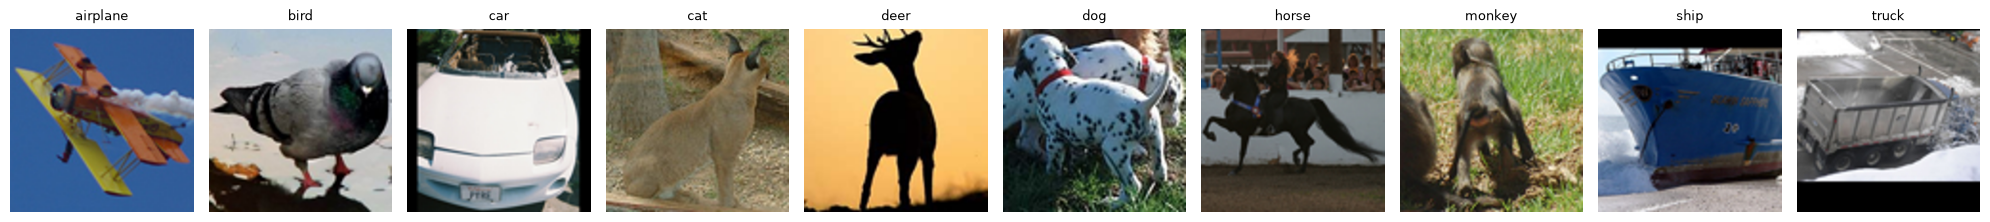

In [5]:
fig, axes = plt.subplots(1, 10, figsize=(20, 2.4))
for c, ax in enumerate(axes):
    j = int(np.where(subset_labels == c)[0][0])
    ax.imshow(clean[j].permute(1, 2, 0).numpy()); ax.set_title(CLASSES[c], fontsize=9); ax.axis("off")
plt.tight_layout(); plt.savefig(RES / "figures" / "subset_examples.png", dpi=120); plt.show()

## 1.5 Stratified 80/20 train/validation split for the linear heads

Performed on the **official training partition** (5000 images) with seed 6304, stratified by class. Only indices are stored; features are extracted in notebook 04.

In [6]:
from sklearn.model_selection import train_test_split

all_train_idx = np.arange(len(train_ds))
tr_idx, va_idx = train_test_split(all_train_idx, test_size=CFG["head"]["val_frac"],
                                  stratify=train_labels, random_state=SEED)
print("train:", len(tr_idx), "val:", len(va_idx))
print("train class counts:", np.bincount(train_labels[tr_idx]))
print("val   class counts:", np.bincount(train_labels[va_idx]))
(RES / "subset" / "head_split.json").write_text(json.dumps(
    {"seed": SEED, "train_idx": tr_idx.tolist(), "val_idx": va_idx.tolist()}))
print("saved head split")

train: 4000 val: 1000
train class counts: [400 400 400 400 400 400 400 400 400 400]
val   class counts: [100 100 100 100 100 100 100 100 100 100]
saved head split
